# Oslo Børs vs. S&P 500
### A historical performance comparison

Comparing the Norwegian stock market (OSEBX) against 
the US market (S&P 500) from 2015 to present.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Download data
obx = yf.download("OBX.OL", start="2015-01-01")["Close"]
sp500 = yf.download("^GSPC", start="2015-01-01")["Close"]

# Normalize to 100
obx_norm = obx / obx.iloc[0] * 100
sp500_norm = sp500 / sp500.iloc[0] * 100

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<function matplotlib.pyplot.show(close=None, block=None)>

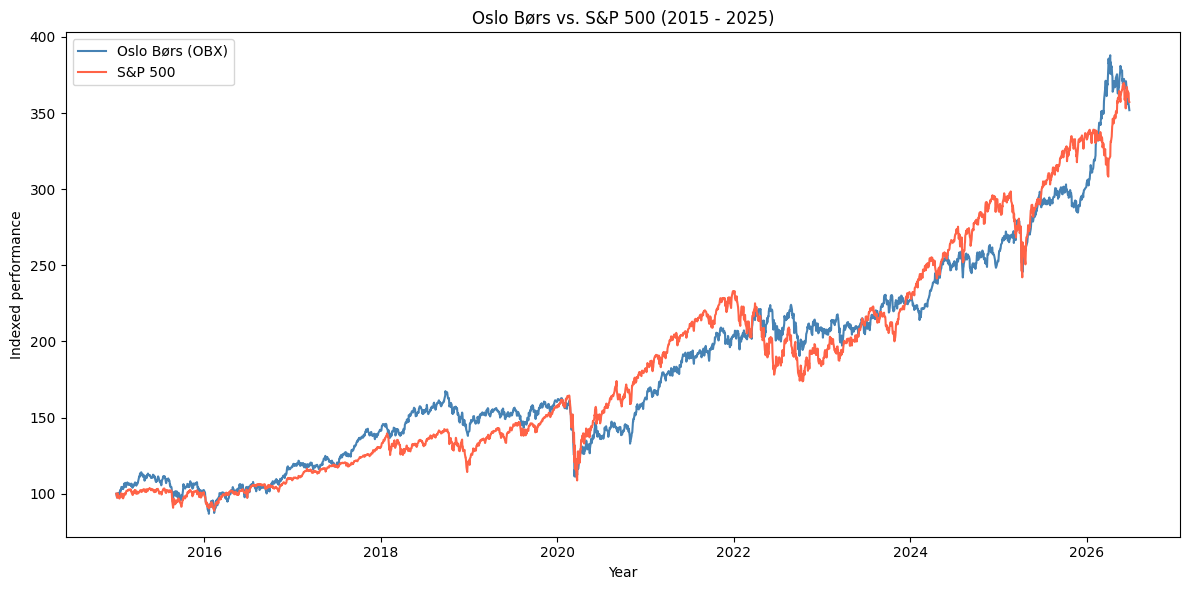

In [3]:
plt.figure(figsize = (12, 6))
plt.plot(obx_norm, label = 'Oslo Børs (OBX)', color = 'steelblue')
plt.plot(sp500_norm, label = 'S&P 500', color = 'tomato')
plt.title('Oslo Børs vs. S&P 500 (2015 - 2025)')
plt.ylabel('Indexed performance')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show


## Key Statistics (2015–2025)

In [4]:
import numpy as np

# Total return
obx_total = (obx_norm.iloc[-1] - 100).values[0]
sp500_total = (sp500_norm.iloc[-1] - 100).values[0]

# Annualized return
years = (obx.index[-1] - obx.index[0]).days / 365.25
obx_annual = ((obx.iloc[-1] / obx.iloc[0]) ** (1 / years) - 1).values[0] * 100
sp500_annual = ((sp500.iloc[-1] / sp500.iloc[0]) ** (1 / years) - 1).values[0] * 100

# Annualized volatility
obx_vol = (obx.pct_change().std() * np.sqrt(252)).values[0] * 100
sp500_vol = (sp500.pct_change().std() * np.sqrt(252)).values[0] * 100

# Print results
print(f"{'':30} {'OBX':>10} {'S&P 500':>10}")
print(f"{'-'*50}")
print(f"{'Total return':30} {obx_total:>9.1f}% {sp500_total:>9.1f}%")
print(f"{'Annualized return':30} {obx_annual:>9.1f}% {sp500_annual:>9.1f}%")
print(f"{'Annualized volatility':30} {obx_vol:>9.1f}% {sp500_vol:>9.1f}%")

                                      OBX    S&P 500
--------------------------------------------------
Total return                       251.9%     257.3%
Annualized return                   11.6%      11.7%
Annualized volatility               17.3%      17.8%


## Annual Returns

In [5]:
# Calculate yearly returns
obx_yearly = obx.resample("YE").last().pct_change() * 100
sp500_yearly = sp500.resample("YE").last().pct_change() * 100

# Combine into one table
yearly = pd.DataFrame({
    "OBX": obx_yearly.squeeze(),
    "S&P 500": sp500_yearly.squeeze()
}).dropna()

yearly.index = yearly.index.year
print(yearly.round(1).to_string())

       OBX  S&P 500
Date               
2016  14.6      9.5
2017  20.2     19.4
2018  -0.5     -6.2
2019  14.1     28.9
2020   1.8     16.3
2021  24.4     26.9
2022   2.0    -19.4
2023   9.5     24.2
2024  11.4     23.3
2025  20.2     16.4
2026  15.9      7.4


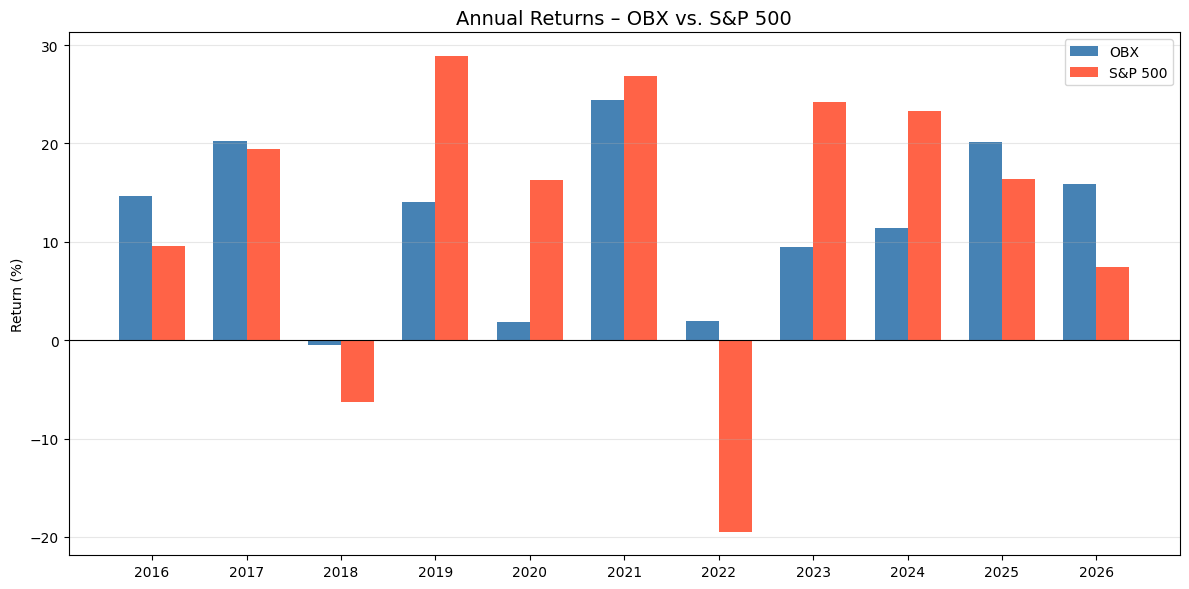

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(yearly.index))
width = 0.35

ax.bar([i - width/2 for i in x], yearly["OBX"], width, label="OBX", color="steelblue")
ax.bar([i + width/2 for i in x], yearly["S&P 500"], width, label="S&P 500", color="tomato")

ax.set_title("Annual Returns – OBX vs. S&P 500", fontsize=14)
ax.set_ylabel("Return (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(yearly.index)
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Thoughts... 

Over the past 10 years, OBX and S&P 500 have actually 
delivered almost identical returns.

The big difference shows up when you look year by year. 
2022 stands out: OBX was basically flat while S&P 500 
dropped 20%. The reason is pretty simple – Oslo Børs 
is dominated by oil and energy companies, which did 
very well when energy prices spiked after the war in 
Ukraine. On the flip side, S&P 500 has crushed OBX in 
years like 2023 and 2024, mostly driven by big tech.

My take: the two markets look similar on paper, but 
they're driven by very different things. If you believe 
in oil and commodities, OBX holds up well. If you 
believe in tech, S&P 500 wins. 

Probably worth looking into how correlated they actually 
are over time – and how much of OBX performance is just 
the oil price in disguise.